In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import joblib
import numpy as np
import pandas as pd
import librosa
import pickle
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [5]:
sample_rate = 22050
audio_files_meta = "metadata.csv"
augmented_meta = "metadata_augmented.csv"
in_dir = "audio_files"
out_dir = "audio_files_augmented"
esc50 = "ESC-50/audio"
esc50_meta = "ESC-50/meta/esc50.csv"
sample_rate = 22050
times = 4
audio_files_meta = "metadata.csv"

In [8]:
df = pd.read_csv(audio_files_meta)
augmented_df = pd.read_csv(augmented_meta)

In [9]:
def extract_features(file_path):
    nmfcc = 13
    y, _ = librosa.load(file_path, sr=sample_rate, mono=True)
    mfcc   = librosa.feature.mfcc(y=y, sr=sample_rate, n_mfcc=nmfcc)
    chroma = librosa.feature.chroma_stft(S=np.abs(librosa.stft(y)), sr=sample_rate)
    rms    = librosa.feature.rms(y=y)
    return np.hstack([mfcc.mean(axis=1), mfcc.std(axis=1),chroma.mean(axis=1), 
                      chroma.std(axis=1),rms.mean(), rms.std()]) 

In [12]:
X, y_raw = [], []
for _, row in augmented_df.iterrows():
    folder = out_dir if row["augmentation"] != "original" else in_dir
    if "wav" in row["file_name"]:
      path   = os.path.join(folder, row["file_name"])
    else:
      path   = os.path.join(folder, row["file_name"]+".wav")

    X.append(extract_features(path))
    y_raw.append(row["emotion"])

X     = np.array(X)
y_raw = np.array(y_raw)
print(f"Feature matrix: {X.shape}  |  Labels: {np.unique(y_raw)}")

le      = LabelEncoder()
y       = le.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

joblib.dump(scaler,os.path.join("models","svm_scaler.gz"))

Feature matrix: (3360, 52)  |  Labels: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'sad' 'surprised']


['models/svm_scaler.gz']

Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best params : {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
              precision    recall  f1-score   support

       angry       0.69      0.70      0.69        96
        calm       0.65      0.75      0.70        96
     disgust       0.61      0.65      0.63        96
     fearful       0.59      0.47      0.52        96
       happy       0.60      0.68      0.64        96
         sad       0.49      0.48      0.48        96
   surprised       0.63      0.56      0.59        96

    accuracy                           0.61       672
   macro avg       0.61      0.61      0.61       672
weighted avg       0.61      0.61      0.61       672



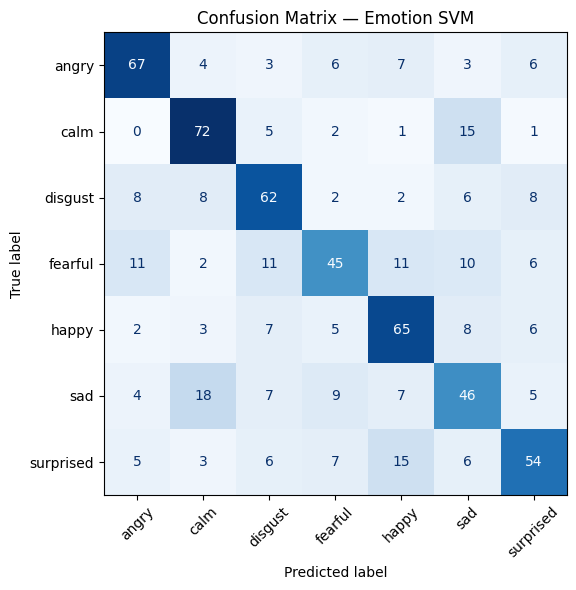

In [13]:
param_grid = {
    "C":     [0.1, 1, 10, 100],
    "gamma": ["scale", 0.001, 0.01, 0.1],
    "kernel": ['rbf','sigmoid'], 
}

cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm = GridSearchCV(
    SVC(class_weight="balanced", probability=True),
    param_grid,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1,
)

svm.fit(X_train, y_train)

with open(os.path.join("models","svm.pkl"),'wb') as f:
    pickle.dump(svm,f)

    
print(f"\nBest params : {svm.best_params_}")

y_pred = svm.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))

cm  = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45
)

ax.set_title("Confusion Matrix — Emotion SVM")
plt.tight_layout()
plt.show()

In [16]:
scaler = joblib.load(os.path.join("models","svm_scaler.gz"))
classes = le.classes_

In [17]:
feature = extract_features("12_Angry_Men.wav")
feature_scaled = scaler.transform([feature])
prediction = svm.predict(feature_scaled).item()
print(f"True Class: angry, Prediction: {classes[prediction]}")

True Class: angry, Prediction: angry
